# 03 – Univariate Feature Analysis
The goals are:
- Understand individual feature distributions
- Detect skewness, sparsity, and long-tail behavior
- Identify features that require transformation or aggregation
- Build intuition for downstream modeling decisions

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("instacart.db")


In [12]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conn = sqlite3.connect("instacart.db")


## Orders per User

This analysis answers:
- How many orders does a typical user place?
- Are most users casual or frequent shoppers?


In [3]:
orders_per_user = pd.read_sql("""
SELECT user_id, COUNT(order_id) AS total_orders
FROM orders
GROUP BY user_id;
""", conn)

orders_per_user.describe()


,user_id,total_orders
count,206209.000000,206209.000000
mean,103105.000000,16.590367
std,59527.555167,16.654774
min,1.000000,4.000000
25%,51553.000000,6.000000
50%,103105.000000,10.000000
75%,154657.000000,20.000000
max,206209.000000,100.000000


## Distribution of Orders per User


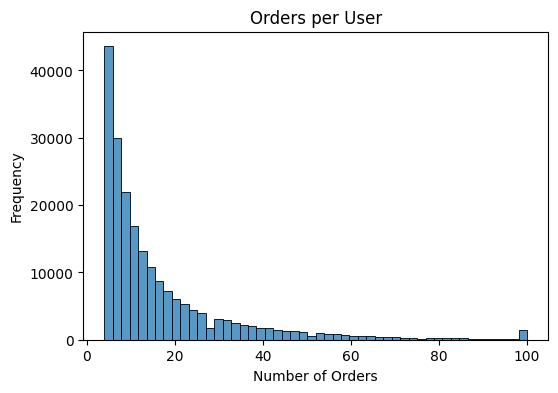

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(orders_per_user["total_orders"], bins=50)
plt.title("Orders per User")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.show()


### User order counts exhibit a long-tailed distribution, indicating heterogeneous user activity with a large proportion of low-activity users(cold start users) and a smaller group of highly active users(power users). This confirms the need for personalized modeling while also motivating hierarchical backoff strategies for cold-start users.

## Product Purchase Frequency
- How often is each product purchased?
- Are most products niche or popular?


In [10]:
product_frequency = pd.read_sql("""
SELECT product_id, COUNT(*) AS purchase_count
FROM order_products_prior
GROUP BY product_id;
""", conn)
product_frequency.describe()


,product_id,purchase_count
count,49677.000000,49677.000000
mean,24843.417356,652.907563
std,14343.034804,4792.114416
min,1.000000,1.000000
25%,12423.000000,17.000000
50%,24842.000000,60.000000
75%,37264.000000,260.000000
max,49688.000000,472565.000000


## Distribution of Product Purchase Frequency

In [ ]:

product_frequency = product_frequency.sort_values("purchase_count")


product_frequency["cum_products"] = np.arange(1, len(product_frequency) + 1) / len(product_frequency)


product_frequency["cum_volume"] = product_frequency["purchase_count"].cumsum()
product_frequency["cum_volume"] = product_frequency["cum_volume"] / product_frequency["purchase_count"].sum()



Text(0.5, 1.0, 'ECDF of Product Reorder Volume (Q3a)')

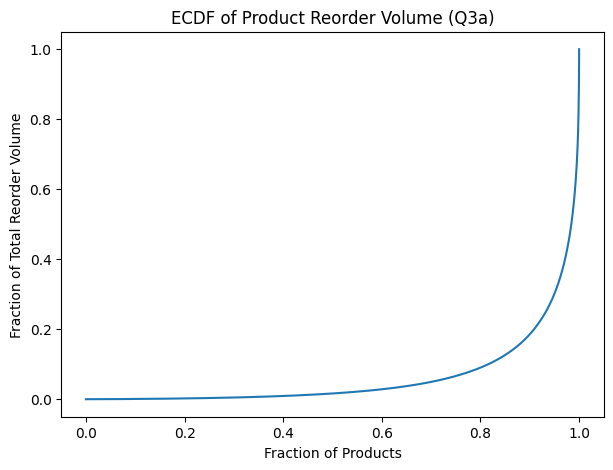

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(
    product_frequency["cum_products"],
    product_frequency["cum_volume"]
)

plt.xlabel("Fraction of Products")
plt.ylabel("Fraction of Total Reorder Volume")
plt.title("ECDF of Product Reorder Volume (Q3a)")



### A few products are reordered many times, while most products are reordered very rarely.This confirms strong product-level heterogeneity and the necessity of hierarchical backoff strategies.

## Product Reorder Ratio

Reorder ratio measures how often a product is repurchased.
This captures product loyalty and habitual consumption.


In [14]:
product_reorder = pd.read_sql("""
SELECT
    product_id,
    AVG(reordered) AS reorder_ratio
FROM order_products_prior
GROUP BY product_id;
""", conn)

product_reorder.describe()


,product_id,reorder_ratio
count,49677.000000,49677.000000
mean,24843.417356,0.366461
std,14343.034804,0.208103
min,1.000000,0.000000
25%,12423.000000,0.208075
50%,24842.000000,0.376623
75%,37264.000000,0.529307
max,49688.000000,0.941176


Text(0.5, 1.0, 'ECDF of Product Reorder Rate ')

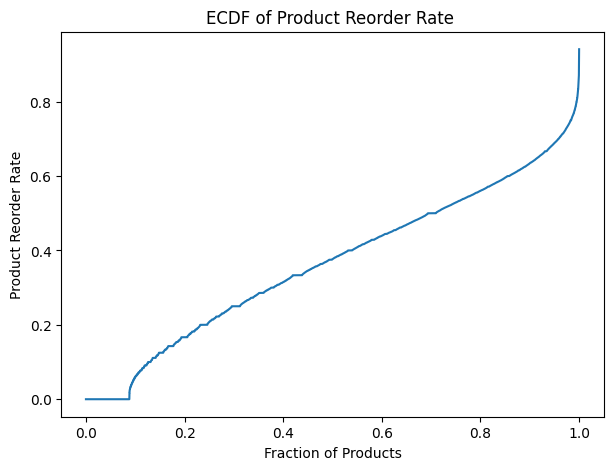

In [ ]:

product_reorder= product_reorder.sort_values("reorder_ratio")

product_reorder["cum_products"] = (
    range(1, len(product_reorder) + 1)
)
product_reorder["cum_products"] /= len(product_reorder)

plt.figure(figsize=(7, 5))
plt.plot(
    product_reorder["cum_products"],
    product_reorder["reorder_ratio"]
)

plt.xlabel("Fraction of Products")
plt.ylabel("Product Reorder Rate")
plt.title("ECDF of Product Reorder Rate ")



### Some products are bought again and again, while many products are rarely bought more than once. This shows that people form strong buying habits for a small number of products, but most products are not part of regular shopping routines.

## Days Since Prior Order

This feature captures user purchase cadence.
Missing values correspond to a user's first order.


In [17]:
days_between = pd.read_sql("""
SELECT days_since_prior_order
FROM orders
WHERE days_since_prior_order IS NOT NULL;
""", conn)

days_between.describe()

,days_since_prior_order
count,3.214874e+06
mean,1.111484e+01
std,9.206737e+00
min,0.000000e+00
25%,4.000000e+00
50%,7.000000e+00
75%,1.500000e+01
max,3.000000e+01


## Distribution of Days Between Orders

We analyze how frequently users return to the platform.


Text(0, 0.5, 'Frequency')

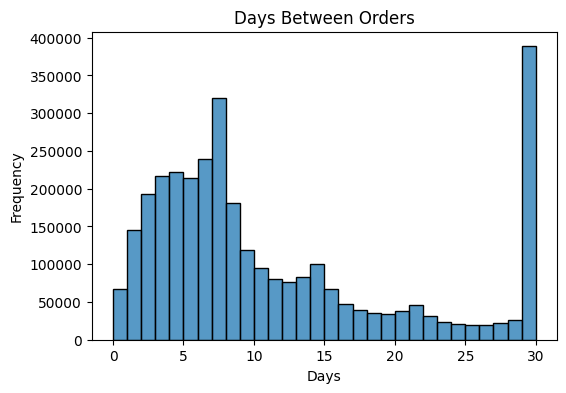

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(days_between["days_since_prior_order"], bins=30)
plt.title("Days Between Orders")
plt.xlabel("Days")
plt.ylabel("Frequency")

### User shopping frequency exhibits clear periodic behavior, with a strong weekly cycle and additional bi-weekly patterns, indicating habitual purchasing for many users. The spike at the maximum interval reflects a group of users with long or irregular shopping gaps rather than a strict monthly shopping cycle. This mixed behavior implies that both recency-based features and long-term aggregate features are necessary for effective reorder prediction.

## Summary

Key observations:
- User activity is highly skewed
- Product demand follows a long-tail distribution
- Reorder behavior is uneven across products
- Purchase cadence varies widely across users

These findings motivate:
- Log or rank-based transformations
- Aggregation at user–product level
- Careful handling of skewed features
